In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Q3: Given data in ”example_regression.csv”, please build a linear regression model for x, y.

In [2]:
### load data
data = pd.read_csv('example_regression.csv', header=0)
data

,x1,x2,y
0,0.35,1.93,7.21
1,0.46,1.90,7.26
2,0.68,1.13,5.93
3,0.90,1.66,7.22
4,0.91,1.50,6.90
...,...,...,...
95,0.13,1.57,6.27
96,0.05,1.11,5.27
97,0.32,1.20,5.73
98,0.35,1.33,5.99


In [3]:
col_names = data.columns
col_names

Index(['x1', 'x2', 'y'], dtype='object')

In [4]:
### get x and y
col_names = data.columns
x = data[col_names[:-1]]
y = data[col_names[-1]]

[0.99583152 2.00031551]
3.0009306910142453


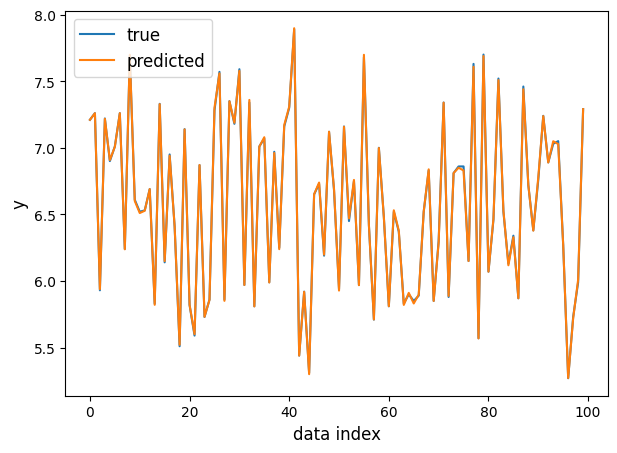

In [5]:
### perform linear regression
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(x, y)    ### y = a + b*x[0] + c*x[1]

print(reg.coef_)        ### values of b and c
print(reg.intercept_)   ### value of a

y_pred = reg.predict(x)

plt.figure(figsize=(7, 5))
plt.plot(y, label='true')
plt.plot(y_pred, label='predicted')
plt.xlabel('data index', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(fontsize=12)
plt.show()

[0.26971888 0.57427282]
6.569


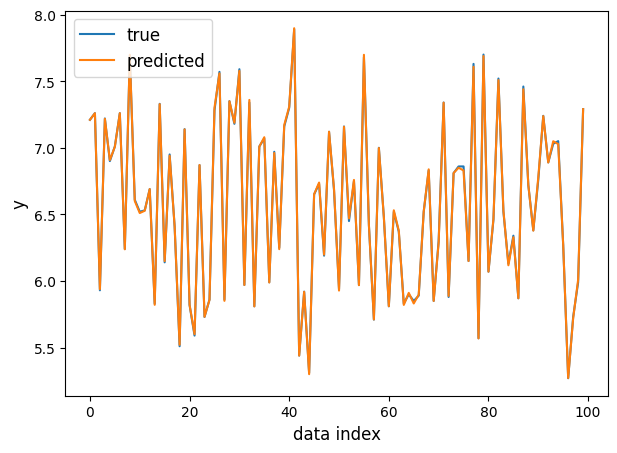

In [6]:
#### do a normalization on x
from sklearn.preprocessing import StandardScaler

x_scale = StandardScaler().fit_transform(x)

reg = LinearRegression().fit(x_scale, y)    ### y = a + b*x[0] + c*x[1]

print(reg.coef_)        ### values of b and c
print(reg.intercept_)   ### value of a

y_pred = reg.predict(x_scale)

plt.figure(figsize=(7, 5))
plt.plot(y, label='true')
plt.plot(y_pred, label='predicted')
plt.xlabel('data index', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.legend(fontsize=12)
plt.show()

In [7]:
### define a function for easier reuse
def do_LR(x, y, figsize=(7, 5), fontsize=12, title=''):
    reg = LinearRegression().fit(x, y)    ### y = a + b*x[0] + c*x[1]
    y_pred = reg.predict(x)

    plt.figure(figsize=figsize)
    plt.plot(y, label='true')
    plt.plot(y_pred, label='predicted')
    plt.xlabel('data index', fontsize=fontsize)
    plt.ylabel('y', fontsize=fontsize)
    plt.legend(fontsize=fontsize)
    plt.title(title, fontsize=fontsize)
    plt.show()
    return reg.coef_, reg.intercept_   ### value of a

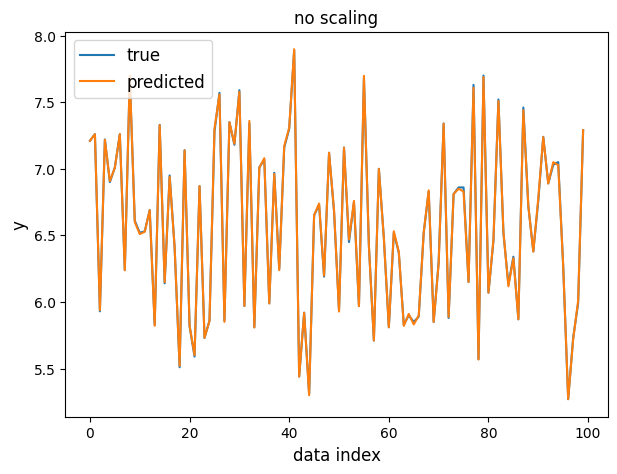

[array([0.99583152, 2.00031551]), 3.0009306910142453]


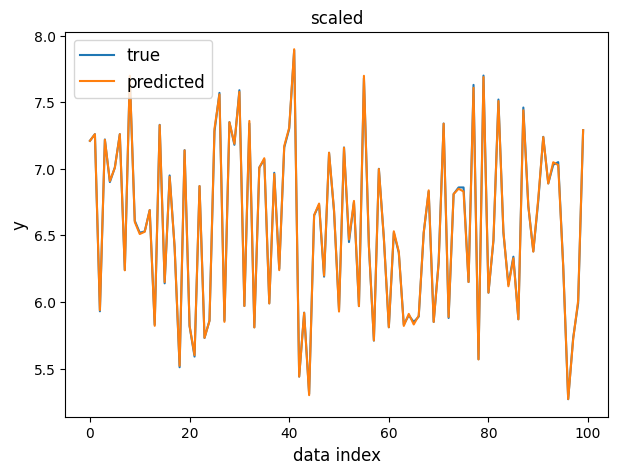

[array([0.26971888, 0.57427282]), 6.569]


In [8]:
coef, intercept = do_LR(x, y, title='no scaling')
print([coef, intercept])
coef_scale, intercept_scale = do_LR(x_scale, y, title='scaled')
print([coef_scale, intercept_scale])

# Q5: Given Raman spectral data measured from six bacterial species, please build a PLS model to predict how likely a spectrum coming from a given species out of the six.

In [9]:
### load data
data = pd.read_csv('regression_spec.csv', header=None)
data

,0,1,2,3,4,5,6,7,8,9,...,1366,1367,1368,1369,1370,1371,1372,1373,1374,1375
0,400.000000,402.000000,404.000000,406.000000,408.000000,410.000000,412.000000,414.000000,416.000000,418.000000,...,3132.000000,3134.000000,3136.000000,3138.000000,3140.000000,3142.000000,3144.000000,3146.000000,3148.000000,3150.000000
1,84.937379,98.640192,112.723668,112.148891,92.819373,65.286688,50.741438,64.905860,85.348355,85.752638,...,8.272385,1.659305,1.213417,11.735347,18.498155,12.135777,7.357331,17.331079,3.924290,-7.792532
2,78.522905,78.907061,71.767214,55.352383,44.379348,56.287620,69.629509,63.861487,50.334463,42.529363,...,10.617955,14.868205,-1.920201,-3.376125,5.407266,-1.539700,-1.884933,5.739901,17.008112,20.223173
3,69.955833,62.103041,68.288369,68.181229,54.916576,36.858955,32.722466,51.905612,64.560699,47.459033,...,-0.681357,14.723803,13.671632,8.550174,6.588864,0.430275,-1.675384,11.100956,18.893334,16.558271
4,42.998646,45.047424,59.829605,79.889410,90.196757,74.613815,50.935755,40.495610,30.743380,6.814787,...,3.816461,11.182517,4.804049,12.241968,21.567314,6.078593,6.116479,16.838943,17.839716,9.595486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,42.685134,42.228533,38.674553,39.596318,44.674205,45.585248,38.874215,24.685294,12.663965,11.987319,...,3.202533,1.275400,4.899594,9.214875,5.738036,-0.413243,4.053142,13.574815,15.047220,9.899284
497,93.668645,86.432942,85.637435,75.687604,62.750819,69.295383,78.062762,66.520725,41.721472,18.383040,...,1.236750,11.473733,10.710447,5.571906,2.902397,2.694357,9.450159,13.807828,5.658991,0.794869
498,81.074428,86.395683,83.485359,82.978839,82.181871,67.190505,47.983108,38.775385,38.753015,42.998653,...,24.551268,4.099367,17.034889,20.147239,2.160935,-1.955958,11.701178,9.656724,2.566634,6.623066
499,80.893759,85.400189,110.693360,114.619251,90.927258,75.643563,73.875155,78.748303,79.171134,66.808488,...,17.427441,16.932948,6.136775,10.087467,15.247717,9.203660,9.158833,15.222781,8.825274,4.312249


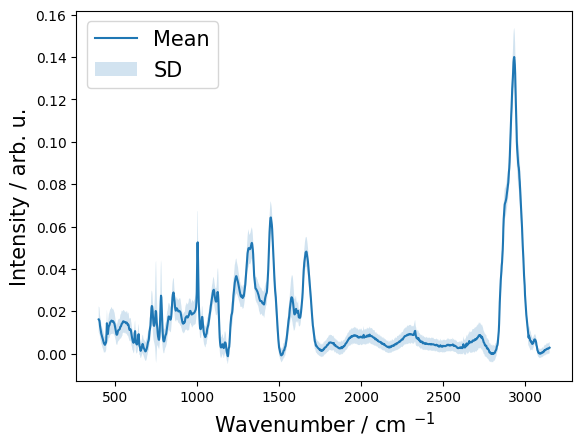

In [10]:
### plot data
wn = np.array(data.iloc[0, :])
spec = data.iloc[1:, :]

spec = np.row_stack([row/np.sqrt(np.sum(row**2)) for i, row in spec.iterrows()])

spec_mean = spec.mean(axis=0)
spec_sd = spec.std(axis=0)

plt.plot(wn, spec_mean, label='Mean')
plt.fill_between(wn, spec_mean - spec_sd, 
                 spec_mean + spec_sd, 
                 alpha = 0.2, label='SD')
plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
plt.ylabel('Intensity / arb. u.', fontsize=15)
plt.legend(fontsize=15)

In [11]:
### load labels
labels = np.array(pd.read_csv('regression_labels.csv', header=0).values)[:,0]
labels[:10]

array(['E-coli', 'E-coli', 'R-terrigena', 'E-coli', 'S-warneri',
       'L-innocua', 'S-warneri', 'E-coli', 'L-innocua', 'R-terrigena'],
      dtype=object)

In [12]:
uni_labels = np.unique(labels)
uni_labels

array(['E-coli', 'L-innocua', 'P-stutzeri', 'R-terrigena', 'S-cohnii',
       'S-warneri'], dtype=object)

In [13]:
### plot mean spectrum of each group
def plot_mean (wn, spec, labels, uni_labels, figsize=(7, 5), fontsize=12, title='', gap=0.05):
    
    plt.figure(figsize=figsize)
    
    for i, l in enumerate(uni_labels):
        spec_mean = spec[labels==l, :].mean(axis=0)
        spec_std = spec[labels==l, :].std(axis=0)
        plt.plot(wn, spec_mean + i*gap, label=l)
        plt.fill_between(wn, spec_mean + i*gap - spec_sd, 
                         spec_mean + i*gap + spec_sd, 
                         alpha = 0.2)
    plt.xlabel("Wavenumber / cm $^{-1}$", fontsize=15)
    plt.ylabel('Intensity / arb. u.', fontsize=15)
    plt.title(title)
    plt.legend(fontsize=15)

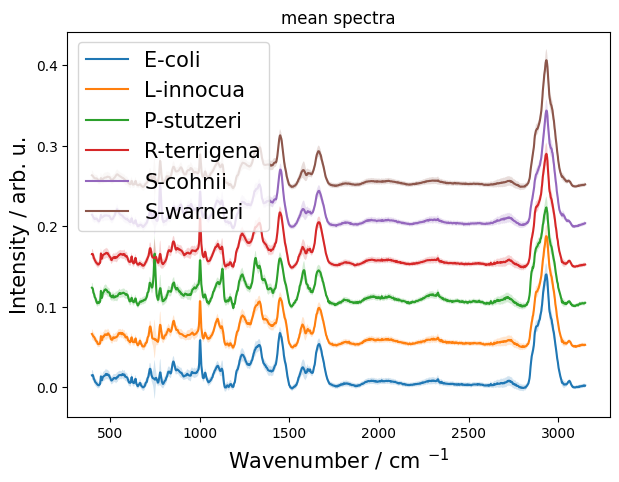

In [14]:
plot_mean(wn, spec, labels, uni_labels, title='mean spectra')

In [15]:
### transfer labels into dummy vectors to perform regression
y_dummy = np.zeros((spec.shape[0], len(uni_labels)))
for i, l in enumerate(uni_labels):
    y_dummy[labels==l, i] = 1
    
y_dummy

array([[1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.]])

In [16]:
### perform partial least sqaures (PLS)
from sklearn.cross_decomposition import PLSRegression
pls = PLSRegression(n_components=10)
pls.fit(spec, y_dummy)
y_pred = pls.predict(spec)
y_pred.round(2)

In [21]:
### calculate error
from sklearn.metrics import mean_squared_error as mse
error = mse(y_dummy, y_pred)
error

0.0345562902090536

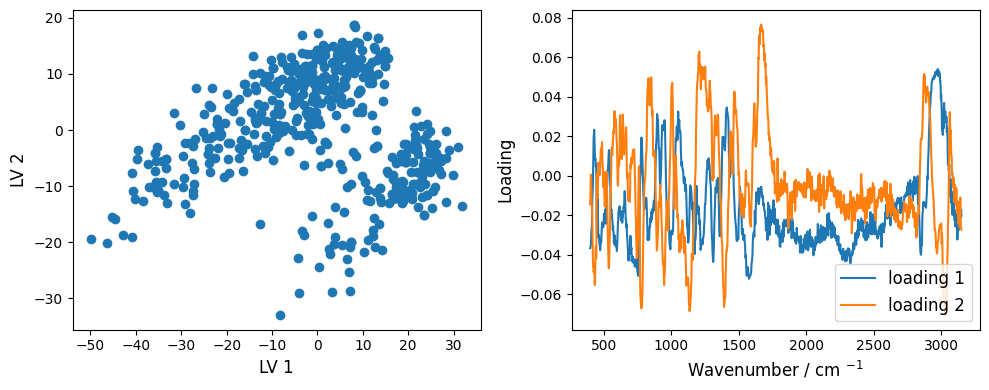

In [24]:
### plot loadings and scores
X_transformed = pls.transform(spec)
X_transformed.shape

x_rotations = pls.x_rotations_
x_rotations.shape

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].scatter(X_transformed[0:, 0], X_transformed[:, 1])
ax[0].set_xlabel('LV 1', fontsize=12)
ax[0].set_ylabel('LV 2', fontsize=12)

ax[1].plot(wn, x_rotations[:, 0], label='loading 1')
ax[1].plot(wn, x_rotations[:, 1], label='loading 2')
ax[1].set_xlabel("Wavenumber / cm $^{-1}$", fontsize=12)
ax[1].set_ylabel('Loading', fontsize=12)
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

In [33]:
### regressian with cross-validation
from sklearn.model_selection import KFold
kf = KFold(n_splits=5, shuffle=True, random_state=1234)

y_pred = np.zeros_like(y_dummy)
error_intermediate = []
for ix_train, ix_test in kf.split(spec):
    x_train, y_train = spec[ix_train, :], y_dummy[ix_train, :]
    x_test, y_test = spec[ix_test, :], y_dummy[ix_test, :]
    
    pls = PLSRegression(n_components=10)
    pls.fit(x_train, y_train)
    y_pred[ix_test, :] = pls.predict(x_test)
    
    error_intermediate.append(mse(y_dummy[ix_test, :], y_pred[ix_test, :]))

print(error_intermediate)

error = mse(y_dummy, y_pred)
print(error)

[0.05801500810927243, 0.056160248320768935, 0.054342991117383194, 0.0550678584483241, 0.06124726270754061]
0.05696667374065786
